In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns',50)
pd.set_option('display.float_format','{:.2f}'.format)
sns.set_theme(style='whitegrid',palette='husl')
print("done")

done


In [3]:
df1=pd.read_excel('C:/Users/Ashut/Retailpulse/data/raw/online_retail_II.xlsx.xlsx',sheet_name='Year 2009-2010')

In [4]:
df2=pd.read_excel('C:/Users/Ashut/Retailpulse/data/raw/online_retail_II.xlsx.xlsx',sheet_name='Year 2010-2011')
df =pd.concat([df1,df2],ignore_index =True)

In [5]:
print(f"shape:{df.shape}")

shape:(1067371, 8)


In [6]:
print(f"Columns: {df.columns.tolist()}")

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [7]:
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [8]:
print("dataset info")

dataset info


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [10]:
print(f"_missing values")

_missing values


In [11]:
df.isnull()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
1067366,False,False,False,False,False,False,False,False
1067367,False,False,False,False,False,False,False,False
1067368,False,False,False,False,False,False,False,False
1067369,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [13]:
df.describe()


,Quantity,InvoiceDate,Price,Customer ID
count,1067371.00,1067371,1067371.00,824364.00
mean,9.94,2011-01-02 21:13:55.394028544,4.65,15324.64
min,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-07-09 09:46:00,1.25,13975.00
50%,3.00,2010-12-07 15:28:00,2.10,15255.00
75%,10.00,2011-07-22 10:23:00,4.15,16797.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,172.71,NaN,123.55,1697.46


In [14]:
df[~df['Invoice'].astype(str).str.startswith('C')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.00,France


In [15]:
df.shape


(1067371, 8)

In [16]:
df=df.dropna(subset=['Customer ID'])

In [17]:
df=df[df['Quantity']>0]

In [18]:
df = df[df['Price'] > 0]

In [19]:
df.shape

(805549, 8)

In [20]:
df['Customer ID']=df['Customer ID'].astype(int)

In [21]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [22]:
df['TotalPrice']=df['Quantity']*df['Price']

In [23]:
df['Customer ID'].nunique()

5878

In [24]:
df['InvoiceDate'].min()

Timestamp('2009-12-01 07:45:00')

In [25]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [26]:
print(df.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
dtype: int64


In [27]:
df.shape

(805549, 9)

In [28]:
print(f"\nFinal clean shape: {df.shape}")
print(f"Date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Unique products: {df['StockCode'].nunique():,}")


Final clean shape: (805549, 9)
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Unique customers: 5,878
Unique products: 4,631


In [29]:
print(df['Quantity'].min())

1


In [30]:
print(df['Price'].min()) 

0.001


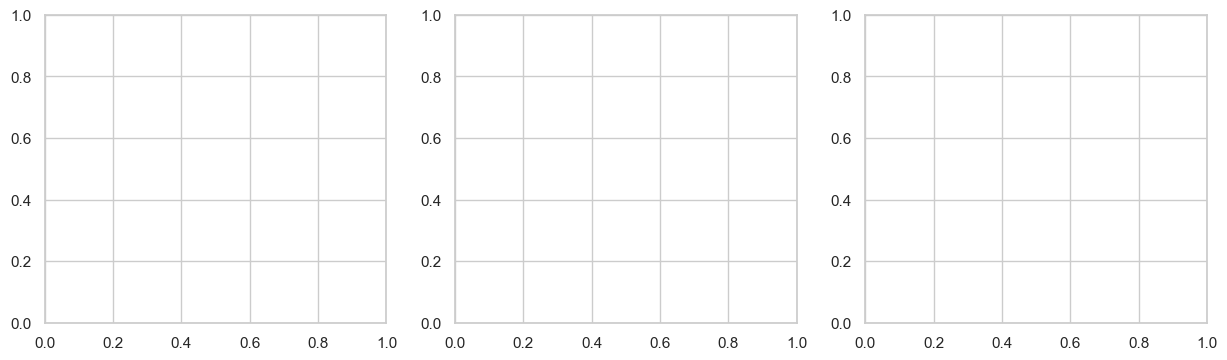

In [31]:
fig,axes =plt.subplots(1,3,figsize=(15,4))
daily =df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()

In [32]:
axes[0].plot(daily.index, daily.values, linewidth=0.8)
axes[0].set_title('Daily Revenue Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue (£)')

Text(4.444444444444459, 0.5, 'Revenue (£)')

In [33]:
top_countries = df.groupby('Country')['TotalPrice']\
                  .sum().nlargest(10)
axes[1].barh(top_countries.index, top_countries.values)
axes[1].set_title('Revenue by Country (Top 10)')
axes[2].hist(df['Quantity'].clip(upper=50), bins=40,
             edgecolor='white', linewidth=0.5)
axes[2].set_title('Quantity Distribution')
axes[2].set_xlabel('Quantity')
plt.tight_layout()
plt.savefig('../reports/01_distributions.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

In [34]:
plt.show()

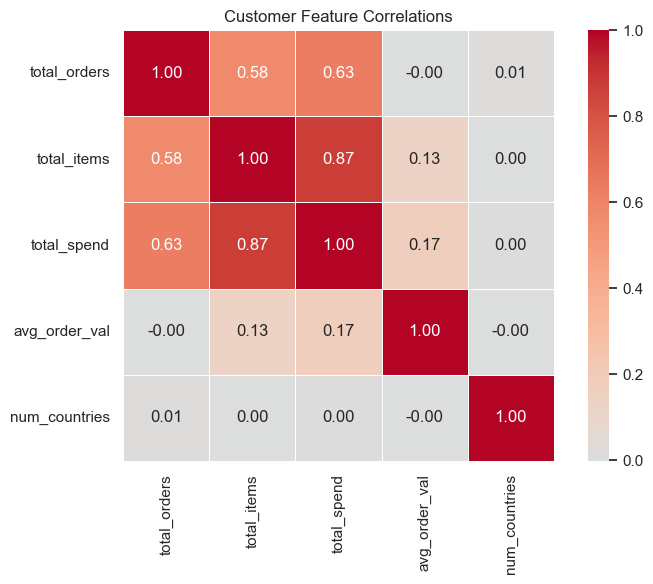

Customer stats shape: (5878, 6)
   Customer ID  total_orders  total_items  total_spend  avg_order_val  \
0        12346            12        74285     77556.46        2281.07   
1        12347             8         3286      5633.32          22.27   
2        12348             5         2714      2019.40          39.60   
3        12349             4         1624      4428.69          25.31   
4        12350             1          197       334.40          19.67   

   num_countries  
0              1  
1              1  
2              1  
3              1  
4              1  


In [35]:
customer_stats = df.groupby('Customer ID').agg(
    total_orders  = ('Invoice', 'nunique'),
    total_items   = ('Quantity', 'sum'),
    total_spend   = ('TotalPrice', 'sum'),
    avg_order_val = ('TotalPrice', 'mean'),
    num_countries = ('Country', 'nunique')
).reset_index()

plt.figure(figsize=(8, 6))
corr = customer_stats.drop('Customer ID', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Customer Feature Correlations')
plt.tight_layout()
plt.savefig('../reports/02_correlation.png', dpi=150)
plt.show()

print(f"Customer stats shape: {customer_stats.shape}")
print(customer_stats.head())

In [36]:
df.to_csv(r'C:\Users\Ashut\Retailpulse\data\processed\retail_clean.csv', index=False)

In [37]:
customer_stats.to_csv(r'C:\Users\Ashut\Retailpulse\data\processed\customer_stats.csv', index=False)